# muMAG Standard Problem #5

A detailed problem description can be found [here](https://www.ctcms.nist.gov/~rdm/std5/spec5.xhtml)

## Google Colab Link

The demo can be run on Google Colab without any local installation.
Use the following [link](https://colab.research.google.com/drive/1AR7ksZUbThvJAn3mTgFKh6ka7dgXbUOb) to try out.

## Install magnum.np and download reference data if not available

In [1]:
!pip install -q magnumnp numpy==1.22.4

In [1]:
from os import path
if not path.isdir("ref"):
    !mkdir ref
    !wget -P ref https://gitlab.com/magnum.np/magnum.np/raw/main/demos/sp5/ref/m.dat

## Run Demo:

In [ ]:
#TODO: read latest script content from gitlab repository, as soon as %load works with Colab
from magnumnp import *
import torch

Timer.enable()

# initialize state
n  = (40, 40, 1)
dx = (2.5e-9, 2.5e-9, 10e-9)
mesh = Mesh(n, dx)

state = State(mesh)
state.material = {
    "Ms": 8e5,
    "A": 1.3e-11,
    "alpha": 0.1,
    "xi": 0.05,
    "b": 72.17e-12
    }

# initialize magnetization that relaxes into s-state
state.m = state.Constant([0,0,0])
state.m[:20,:,:,1] = -1.
state.m[20:,:,:,1] = 1.
state.m[20,20,:,1] = 0.
state.m[20,20,:,2] = 1.

state.j = state.Tensor([1e12, 0, 0])

# initialize field terms
demag    = DemagField()
exchange = ExchangeField()
torque   = SpinTorqueZhangLi()

# initialize sstate
llg = LLGSolver([demag, exchange])
llg.relax(state)
write_vti(state.m, "data/m0.vti", state)

# perform integration with spin torque
llg = LLGSolver([demag, exchange, torque])
logger = Logger("data", ['t', 'm'], ["m"])
while state.t < 5e-9:
    llg.step(state, 1e-11)
    logger << state

Timer.print_report()

## Plot Results

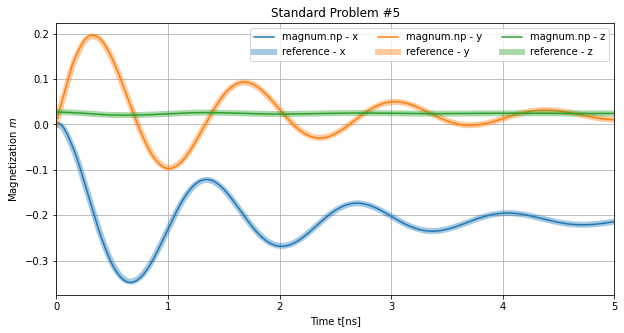

In [4]:
#TODO: read latest script content from gitlab repository, as soon as %load works with Colab

import matplotlib.pyplot as plt
import numpy as np

data = np.loadtxt("data/log.dat")
ref = np.loadtxt("ref/m.dat")

fig, ax = plt.subplots(figsize=(10,5))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

ax.plot(data[:,0]*1e9, data[:,1], '-', color = cycle[0], label = "magnum.np - x")
ax.plot(ref[:,0]*1e9, ref[:,1], '-', color = cycle[0], linewidth = 6, alpha = 0.4, label = "reference - x")

ax.plot(data[:,0]*1e9, data[:,2], '-', color = cycle[1], label = "magnum.np - y")
ax.plot(ref[:,0]*1e9, ref[:,2], '-', color = cycle[1], linewidth = 6, alpha = 0.4, label = "reference - y")

ax.plot(data[:,0]*1e9, data[:,3], '-', color = cycle[2], label = "magnum.np - z")
ax.plot(ref[:,0]*1e9, ref[:,3], '-', color = cycle[2], linewidth = 6, alpha = 0.4, label = "reference - z")

ax.set_xlim([0,5])
ax.set_title("Standard Problem #5")
ax.set_xlabel("Time t[ns]")
ax.set_ylabel("Magnetization $m$")
ax.legend(ncol=3)
ax.grid()
fig.savefig("data/results.png")
